<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/AlexNet_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/dataset_locale/
!unzip -q "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset_locale/"

import os
print(os.listdir("/content/dataset_locale/"))

['Data']


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

data_dir = "/content/dataset_locale/Data"

# 1. Define the trasformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir)


# Divide in 70% Train, 10% Validation and 20% Test
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
test_size = int(0.20 * total_size)
val_size = total_size - train_size - test_size

train_raw, test_raw, val_raw = random_split(full_dataset, [train_size, test_size, val_size])

# Class for the application of the trsformations
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# transformation application
train_dataset = ApplyTransform(train_raw, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_raw, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_raw, transform=data_transforms['val'])

# Create the final dataLoader
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training imagines: {len(train_dataset)}")
print(f"Validation imagines: {len(val_dataset)}")
print(f"Test imagines: {len(test_dataset)}")

Training imagines: 8400
Validation imagines: 1200
Test imagines: 2400


In [7]:
import torch
from torch import nn

net = nn.Sequential(
    # 1. Conv
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 2. Conv
    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # 3, 4, 5 Conv
    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 12)
)

In [6]:
# Install the d2l library
!pip install -q d2l==1.0.a1.post0
from d2l import torch as d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.5 MB/s eta 0:00:00


Start the train on cuda...
Epoch [1/50] | Train Loss: 2.7560 | Val Loss: 2.3311 | Val Acc: 19.50%
--> Improvement! Model saving... (Accuracy: 0.00% -> 19.50%)
Epoch [2/50] | Train Loss: 2.3505 | Val Loss: 2.2721 | Val Acc: 22.08%
--> Improvement! Model saving... (Accuracy: 19.50% -> 22.08%)
Epoch [3/50] | Train Loss: 2.2925 | Val Loss: 2.2057 | Val Acc: 26.42%
--> Improvement! Model saving... (Accuracy: 22.08% -> 26.42%)
Epoch [4/50] | Train Loss: 2.2178 | Val Loss: 2.1567 | Val Acc: 27.67%
--> Improvement! Model saving... (Accuracy: 26.42% -> 27.67%)
Epoch [5/50] | Train Loss: 2.1484 | Val Loss: 2.0625 | Val Acc: 33.33%
--> Improvement! Model saving... (Accuracy: 27.67% -> 33.33%)


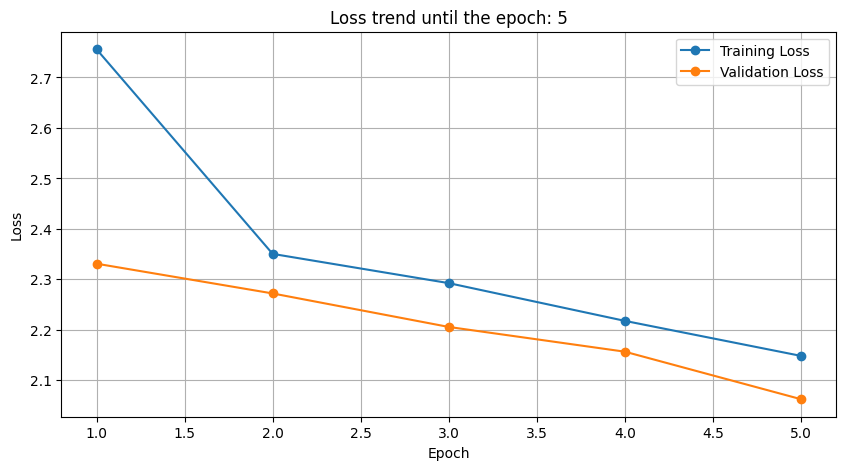

Epoch [6/50] | Train Loss: 2.1021 | Val Loss: 2.0881 | Val Acc: 31.92%
Epoch [7/50] | Train Loss: 2.0633 | Val Loss: 2.0449 | Val Acc: 31.08%
Epoch [8/50] | Train Loss: 2.0209 | Val Loss: 1.9717 | Val Acc: 37.25%
--> Improvement! Model saving... (Accuracy: 33.33% -> 37.25%)
Epoch [9/50] | Train Loss: 1.9908 | Val Loss: 2.0303 | Val Acc: 35.33%
Epoch [10/50] | Train Loss: 1.9455 | Val Loss: 1.8982 | Val Acc: 38.83%
--> Improvement! Model saving... (Accuracy: 37.25% -> 38.83%)


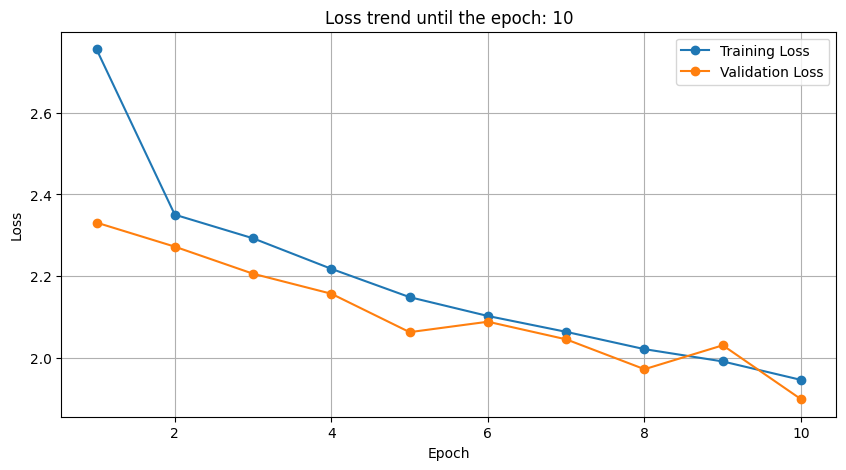

Epoch [11/50] | Train Loss: 1.9114 | Val Loss: 1.8704 | Val Acc: 41.67%
--> Improvement! Model saving... (Accuracy: 38.83% -> 41.67%)
Epoch [12/50] | Train Loss: 1.8672 | Val Loss: 1.8216 | Val Acc: 43.58%
--> Improvement! Model saving... (Accuracy: 41.67% -> 43.58%)
Epoch [13/50] | Train Loss: 1.8561 | Val Loss: 1.8166 | Val Acc: 43.58%
Epoch [14/50] | Train Loss: 1.8163 | Val Loss: 1.8029 | Val Acc: 45.75%
--> Improvement! Model saving... (Accuracy: 43.58% -> 45.75%)
Epoch [15/50] | Train Loss: 1.7763 | Val Loss: 1.7070 | Val Acc: 49.25%
--> Improvement! Model saving... (Accuracy: 45.75% -> 49.25%)


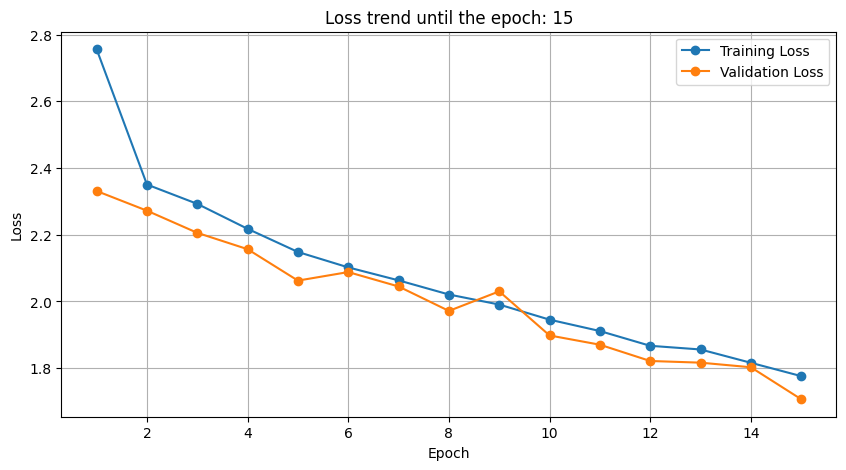

Epoch [16/50] | Train Loss: 1.7425 | Val Loss: 1.7445 | Val Acc: 47.08%
Epoch [17/50] | Train Loss: 1.7036 | Val Loss: 1.7234 | Val Acc: 50.00%
--> Improvement! Model saving... (Accuracy: 49.25% -> 50.00%)
Epoch [18/50] | Train Loss: 1.6657 | Val Loss: 1.6827 | Val Acc: 50.92%
--> Improvement! Model saving... (Accuracy: 50.00% -> 50.92%)
Epoch [19/50] | Train Loss: 1.6543 | Val Loss: 1.6619 | Val Acc: 49.67%
Epoch [20/50] | Train Loss: 1.6019 | Val Loss: 1.6218 | Val Acc: 53.50%
--> Improvement! Model saving... (Accuracy: 50.92% -> 53.50%)


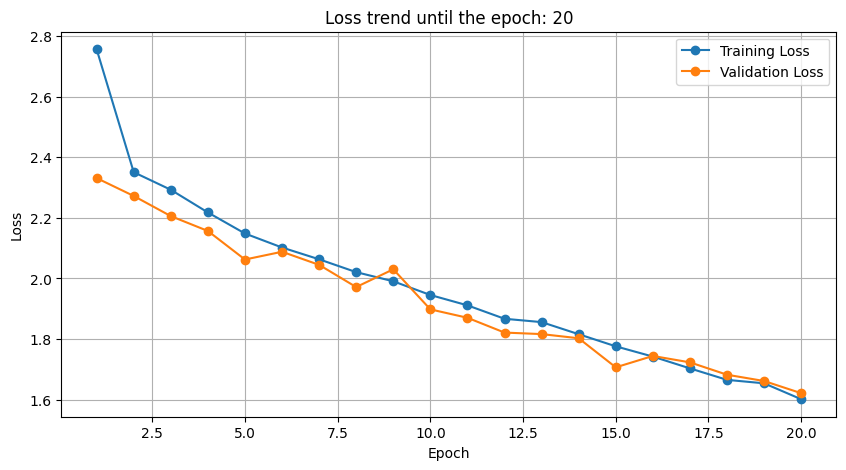

Epoch [21/50] | Train Loss: 1.5618 | Val Loss: 1.5769 | Val Acc: 55.92%
--> Improvement! Model saving... (Accuracy: 53.50% -> 55.92%)
Epoch [22/50] | Train Loss: 1.5231 | Val Loss: 1.6194 | Val Acc: 53.75%
Epoch [23/50] | Train Loss: 1.4833 | Val Loss: 1.5551 | Val Acc: 57.17%
--> Improvement! Model saving... (Accuracy: 55.92% -> 57.17%)
Epoch [24/50] | Train Loss: 1.4458 | Val Loss: 1.5803 | Val Acc: 53.67%
Epoch [25/50] | Train Loss: 1.4123 | Val Loss: 1.4823 | Val Acc: 59.92%
--> Improvement! Model saving... (Accuracy: 57.17% -> 59.92%)


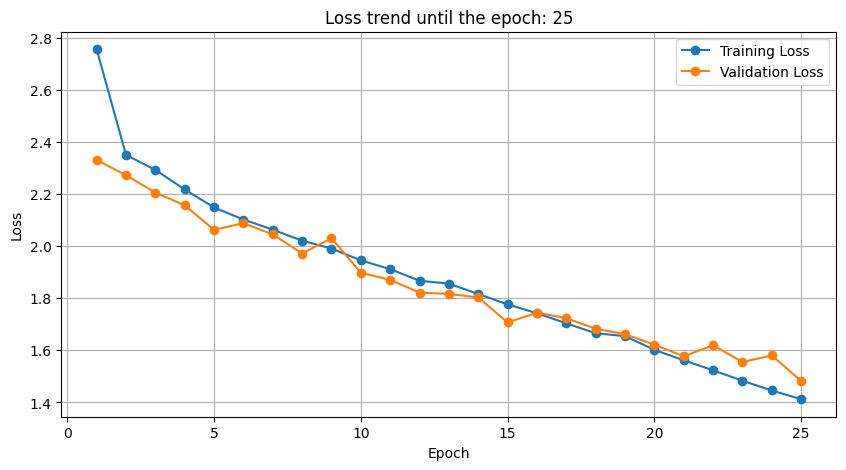

Epoch [26/50] | Train Loss: 1.3770 | Val Loss: 1.4486 | Val Acc: 63.00%
--> Improvement! Model saving... (Accuracy: 59.92% -> 63.00%)
Epoch [27/50] | Train Loss: 1.3520 | Val Loss: 1.4489 | Val Acc: 63.00%
Epoch [28/50] | Train Loss: 1.3255 | Val Loss: 1.3976 | Val Acc: 64.67%
--> Improvement! Model saving... (Accuracy: 63.00% -> 64.67%)
Epoch [29/50] | Train Loss: 1.2740 | Val Loss: 1.3734 | Val Acc: 65.83%
--> Improvement! Model saving... (Accuracy: 64.67% -> 65.83%)
Epoch [30/50] | Train Loss: 1.2475 | Val Loss: 1.3691 | Val Acc: 66.08%
--> Improvement! Model saving... (Accuracy: 65.83% -> 66.08%)


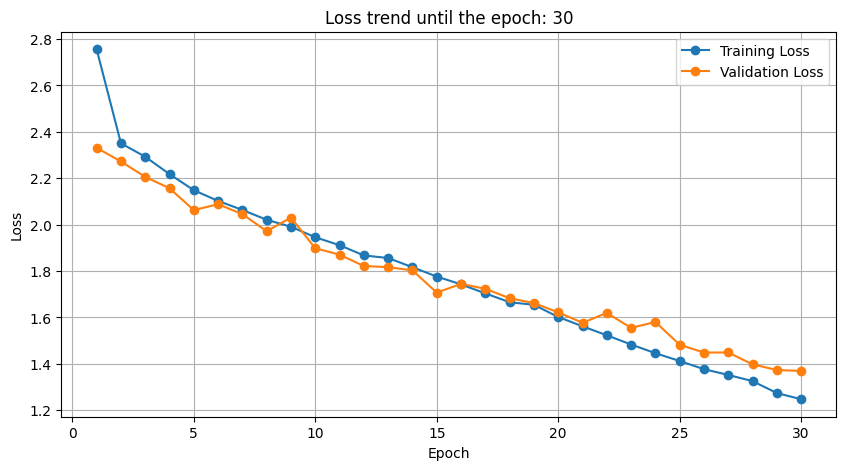

Epoch [31/50] | Train Loss: 1.2299 | Val Loss: 1.3927 | Val Acc: 64.83%
Epoch [32/50] | Train Loss: 1.2014 | Val Loss: 1.3252 | Val Acc: 70.33%
--> Improvement! Model saving... (Accuracy: 66.08% -> 70.33%)
Epoch [33/50] | Train Loss: 1.1659 | Val Loss: 1.3063 | Val Acc: 70.83%
--> Improvement! Model saving... (Accuracy: 70.33% -> 70.83%)
Epoch [34/50] | Train Loss: 1.1341 | Val Loss: 1.2864 | Val Acc: 71.75%
--> Improvement! Model saving... (Accuracy: 70.83% -> 71.75%)
Epoch [35/50] | Train Loss: 1.1285 | Val Loss: 1.3270 | Val Acc: 67.42%


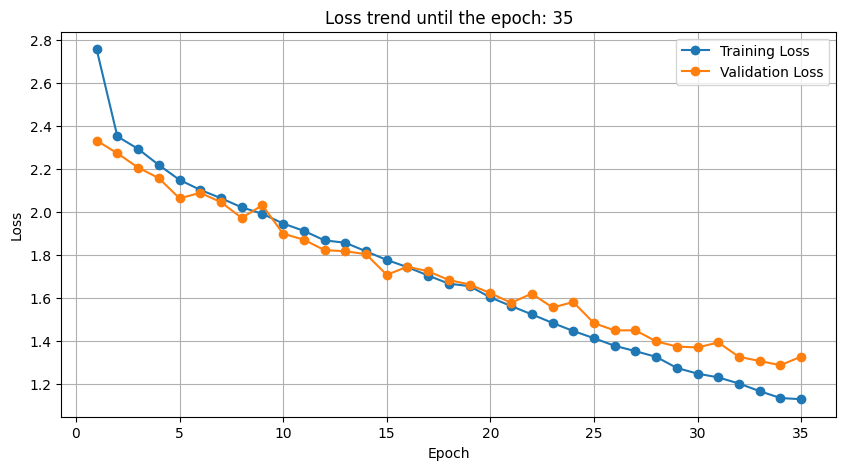

Epoch [36/50] | Train Loss: 1.0986 | Val Loss: 1.2766 | Val Acc: 70.92%
Epoch [37/50] | Train Loss: 1.0853 | Val Loss: 1.2565 | Val Acc: 72.17%
--> Improvement! Model saving... (Accuracy: 71.75% -> 72.17%)
Epoch [38/50] | Train Loss: 1.0674 | Val Loss: 1.2389 | Val Acc: 73.92%
--> Improvement! Model saving... (Accuracy: 72.17% -> 73.92%)
Epoch [39/50] | Train Loss: 1.0511 | Val Loss: 1.2317 | Val Acc: 73.58%
Epoch [40/50] | Train Loss: 1.0403 | Val Loss: 1.2198 | Val Acc: 74.50%
--> Improvement! Model saving... (Accuracy: 73.92% -> 74.50%)


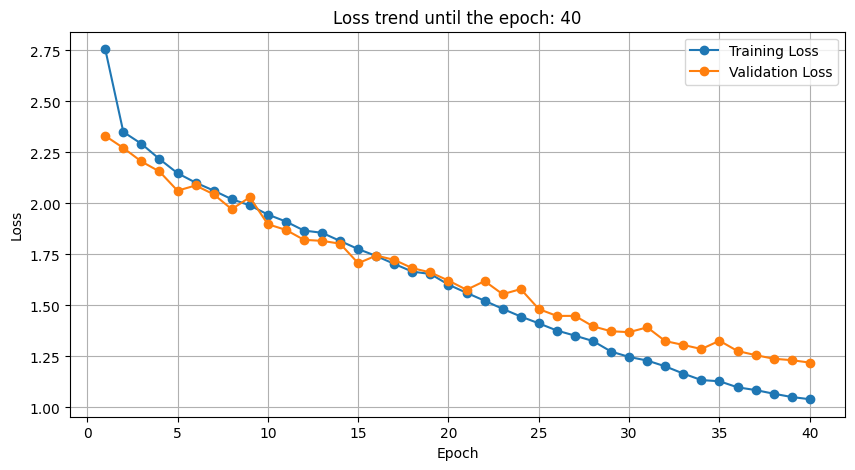

Epoch [41/50] | Train Loss: 1.0251 | Val Loss: 1.2191 | Val Acc: 73.92%
Epoch [42/50] | Train Loss: 1.0266 | Val Loss: 1.2062 | Val Acc: 74.42%
Epoch [43/50] | Train Loss: 0.9969 | Val Loss: 1.2142 | Val Acc: 74.75%
--> Improvement! Model saving... (Accuracy: 74.50% -> 74.75%)
Epoch [44/50] | Train Loss: 0.9983 | Val Loss: 1.1991 | Val Acc: 75.33%
--> Improvement! Model saving... (Accuracy: 74.75% -> 75.33%)
Epoch [45/50] | Train Loss: 0.9941 | Val Loss: 1.2023 | Val Acc: 74.92%


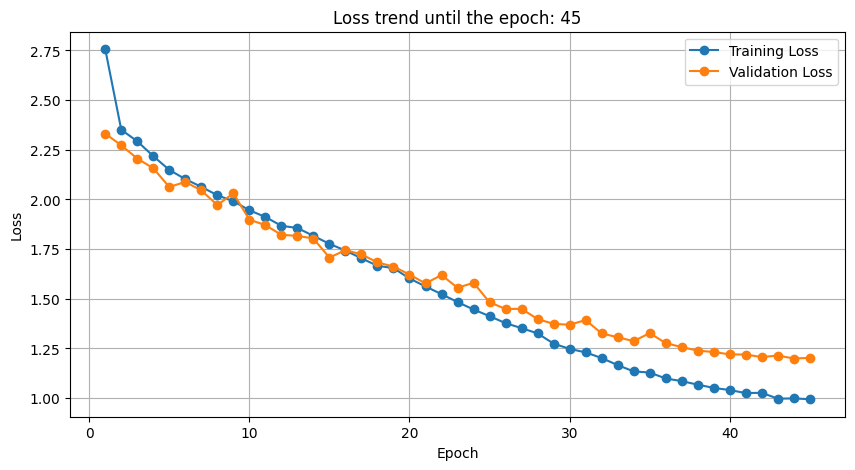

Epoch [46/50] | Train Loss: 0.9902 | Val Loss: 1.1956 | Val Acc: 75.00%
Epoch [47/50] | Train Loss: 0.9963 | Val Loss: 1.1997 | Val Acc: 75.17%
Epoch [48/50] | Train Loss: 0.9770 | Val Loss: 1.2008 | Val Acc: 74.83%
Epoch [49/50] | Train Loss: 0.9856 | Val Loss: 1.1994 | Val Acc: 75.33%
Epoch [50/50] | Train Loss: 0.9727 | Val Loss: 1.1943 | Val Acc: 75.92%
--> Improvement! Model saving... (Accuracy: 75.33% -> 75.92%)


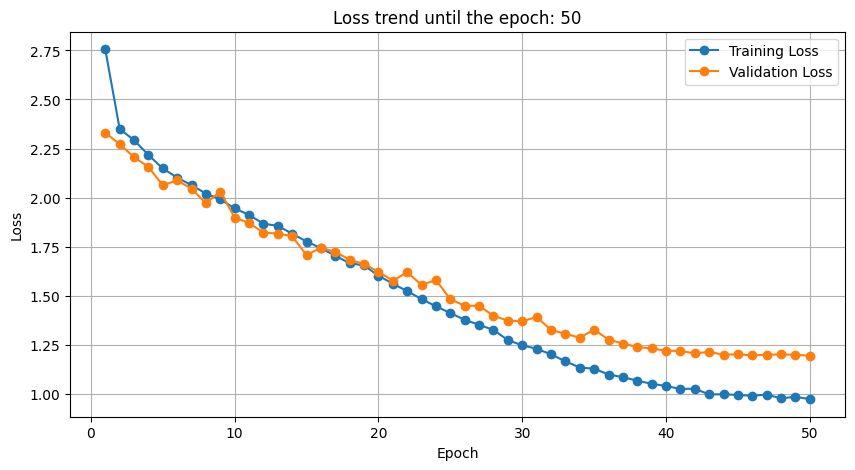

------------------------------
Trained completed! Best accuracy reached: 75.92%


In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import torch.optim as optim
from IPython.display import clear_output

# initial settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)
net.to(device)

# Parameters
lr = 0.0002
num_epochs = 50

# Optimizer, loss and scheduler
optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_acc = 0.0
train_losses = []
val_losses = []

print(f"Start the train on {device}...")

# TRAIN
for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    net.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc

    # Plot
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")

In [ ]:
save_path = '/content/drive/MyDrive/Deep_learning_project/mushroom_alexnet5.pth'

**Confusion matrix**

>



Prediction computation on the TEST SET...


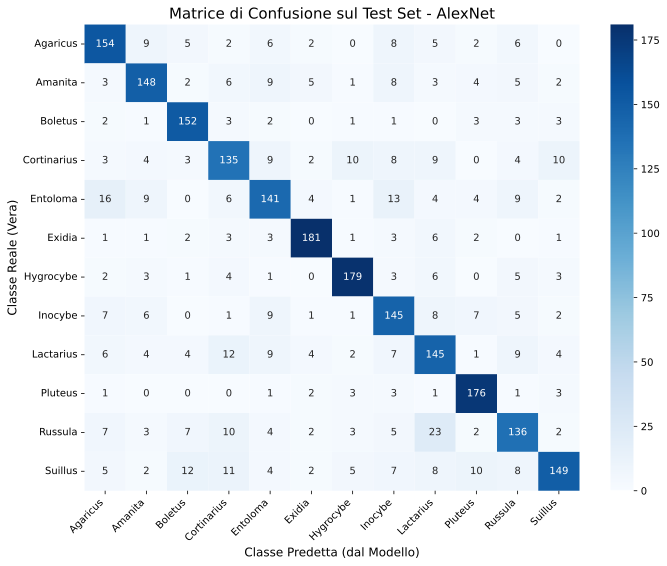

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_scores = []
y_pred = []

print("Prediction computation on the TEST SET...")

net.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(d2l.try_gpu())
        outputs = net(X)

        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_pred = np.array(y_pred)

class_names = full_dataset.classes

# confusion matrix graph
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Classe Predetta (dal Modello)', fontsize=12)
plt.ylabel('Classe Reale (Vera)', fontsize=12)
plt.title('Matrice di Confusione sul Test Set - AlexNet', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**ROC Curve**

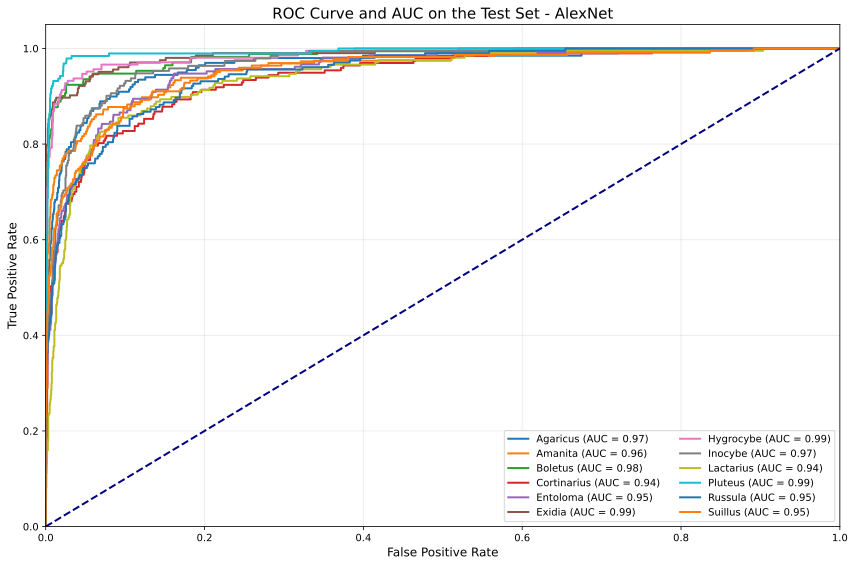

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve and AUC on the Test Set - AlexNet', fontsize=15)
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()